# Frequency-domain activity correction

Planet hunters know that stellar activity signals such as rotation, granulation, and magnetic activity cycles manifest in radial velocities (RVs). When the stellar signals are quasiperiodic, they may be mistaken for planets, as has happened for [Barnard's star](https://ui.adsabs.harvard.edu/abs/2021AJ....162...61L/abstract) and [HD 26965](https://ui.adsabs.harvard.edu/abs/2024AJ....167..243B/abstract). Broad-spectrum processes such as granulation can mask planet discoveries by adding noise to the radial velocity time series.

It would be great if we could use activity indicators to predict the stellar RV variability. Such indicators are sensitive to magnetic energy release in the star chromosphere, which changes the velocity of gas at the star surface. However, they do not respond to Doppler shifts caused by planets. If an oscillation shows up in an activity indicator time series, we know it comes from the stellar atmosphere instead of a planet. Our goal is subtract off the radial velocity signature of stellar variability, leaving behind only the oscillations caused by planets.

The Extreme Stellar Signals Project datasets come with five activity indicators: full width at half maximum of the RV cross-correlation function (CCF FWHM), cross-correlation function contrast (CCF contrast), bisector span (BIS), H$\alpha$ emission, and emission from ionized calcium atoms (Ca II). In statistical terminology, we want to use the activity indicators as <em>explanatory variables</em> for the RVs. A common way to set up such a problem is with a [multiple linear regression](https://web.stanford.edu/class/stats202//notes/Linear-regression/Multiple-linear-regression.html).

The activity indicators form five time series $x_{1,n}$, $x_{2,n}$, $x_{3,n}$, $x_{4,n}$, and $x_{5,n}$, where $n = 1, 2, \ldots, N$ and $N$ is the number of observations. The $x_{1,n}, x_{2,n}, \ldots$ are measured at the same times as the RVs, which we will call $y_n$. The multiple linear regression is expressed as 

$y_n = \beta_0 + \beta_1 x_{1,n} + \beta_2 x_{2,n} + \beta_3 x_{3,n} + \beta_4 x_{4,n} + \beta_5 x_{5,n} + \epsilon_n$.

$\epsilon_n$ is an error term, and the best-fit coefficients $\beta_0, \beta_1, \ldots, \beta_5$ are found by minimizing $\sum_{n=1}^N \epsilon_n^2$.

But what if there are lead-lag relationships between activity indicators and RVs? Consider this simple example:

In [35]:
import numpy as np
import matplotlib.pyplot as plt
#make better plots
import scienceplots
plt.style.use(['science','notebook','grid'])
plt.rcParams.update({"font.size" : 26})
plt.rcParams.update({"axes.labelsize" : 26})
plt.rcParams.update({"xtick.labelsize" : 22})
plt.rcParams.update({"ytick.labelsize" : 22})
plt.rcParams.update({"axes.titlesize" : 26})
plt.rcParams.update({"figure.figsize": (9,6)})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [2]:
f_ex = 0.025
t_ex = np.linspace(0, 100, num=101, endpoint=True)
x_ex = np.cos(2*np.pi * f_ex * t_ex)
y_ex = np.sin(2*np.pi * f_ex * t_ex)

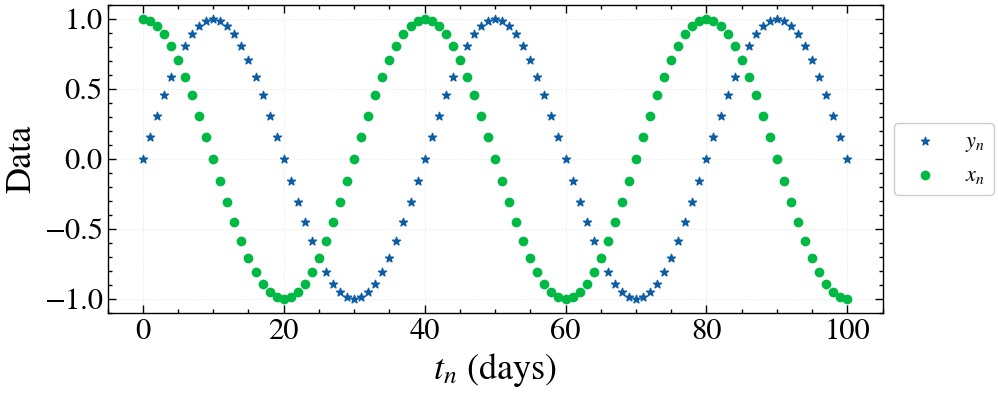

In [3]:
plt.figure(figsize=(10,4))
plt.scatter(t_ex, y_ex, marker='*', label=r"$y_n$")
plt.scatter(t_ex, x_ex, label=r"$x_n$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel(r"$t_n$ (days)")
plt.ylabel('Data')
plt.grid(color='0.85')

In the time series shown above, there is no single coefficient that maps $x_n$ onto $y_n$: sometimes $x_n < y_n$, sometimes $x_n > y_n$, and sometimes the two are equal. However, a <em>lagged regression</em> would be an excellent model: $y_n = x_{n-10}$.

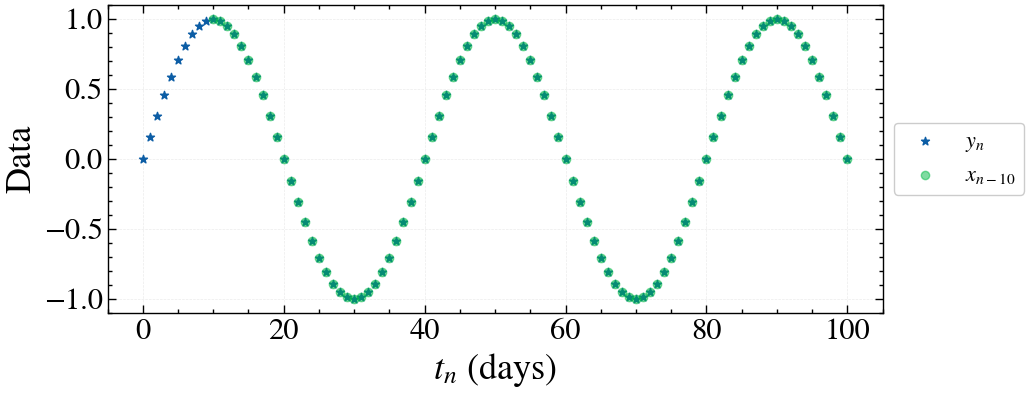

In [4]:
plt.figure(figsize=(10,4))
plt.scatter(t_ex, y_ex, marker='*', label=r"$y_n$")
plt.scatter(t_ex[10:], x_ex[:-10], label=r"$x_{n-10}$", alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel(r"$t_n$ (days)")
plt.ylabel('Data')
plt.grid(color='0.85')

Since $y_n$ may depend on more than one previous value of $x_n$, the general form of a lagged regression is

$y_n = \beta_0 + \sum_{m=1}^M \beta_m x_{n-m}$.

A <em>multiple lagged regression</em> for the ESSP data would have the form

$y_n = \beta_0 + \sum_{m=1}^M \beta_{1,m} x_{1,n-m} + \sum_{m=1}^M \beta_{2,m} x_{2,n-m} + \ldots + \sum_{m=1}^M \beta_{5,m} x_{5,n-m}$.

The problem with lagged regressions is that they can't be straightforwardly applied to time series with uneven time intervals. In the figure above, $\Delta t = t_n - t_{n-1}$ is constant for all $n$, so $y_n$ and $x_{n-10}$ are always separated in time by exactly 10 days. Here is the same lag experiment for unevenly sampled data:

In [5]:
np.random.seed(4321) # For reproducibility

t_uneven = np.random.uniform(low=0, high=100, size=101)
x_uneven = np.cos(2*np.pi * f_ex * t_uneven)
y_uneven = np.sin(2*np.pi * f_ex * t_uneven)

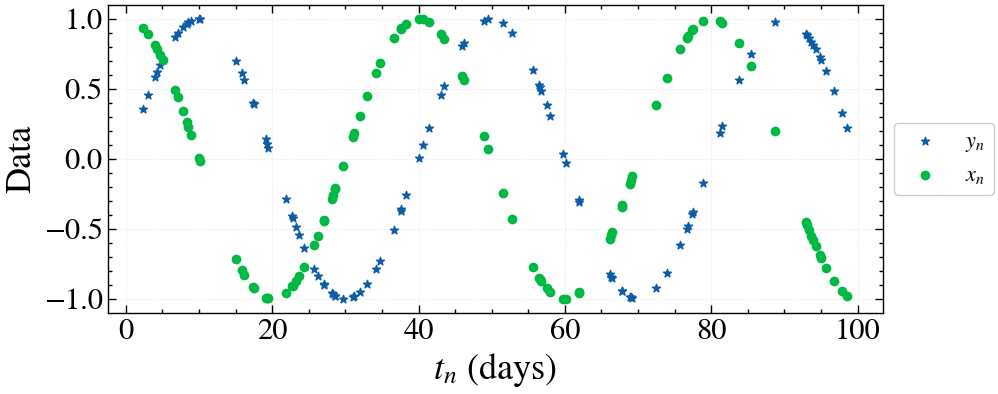

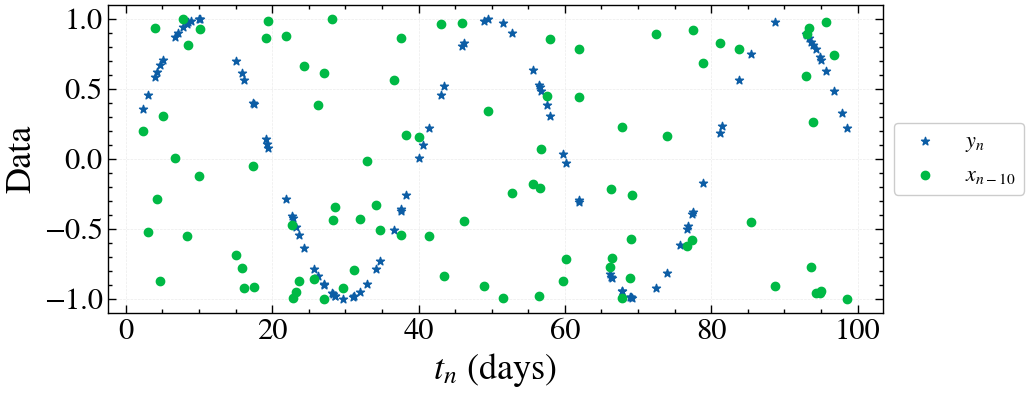

In [6]:
plt.figure(figsize=(10,4))
plt.scatter(t_uneven, y_uneven, marker='*', label=r"$y_n$")
plt.scatter(t_uneven, x_uneven, label=r"$x_n$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel(r"$t_n$ (days)")
plt.ylabel('Data')
plt.grid(color='0.85')

plt.figure(figsize=(10,4))
plt.scatter(t_uneven, y_uneven, marker='*', label=r"$y_n$")
plt.scatter(t_uneven[10:], x_uneven[:-10], label=r"$x_{n-10}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel(r"$t_n$ (days)")
plt.ylabel('Data')
plt.grid(color='0.85')

When the time interval between $y_n$ and $x_{n-10}$ can vary, it's not generally true that $y_n = x_{n-10}$, even though the underlying signals are the same as in the evenly spaced time series shown above.

## Multiple regression in the frequency domain

Suppose that instead of performing the regression in the time domain, we shift to the frequency domain. The discrete Fourier transform of an evenly sampled time series (constant $\Delta t \equiv 1$) is

#### $\tilde{x}(f) = \sum_{n=1}^N x_n e^{-2 \pi i f n}$.

When the time series is non-uniformly sampled, we can use the [<tt>FINUFFT</tt>](https://finufft.readthedocs.io/en/latest/index.html) (Flatiron Institute non-uniform fast Fourier transform) library to estimate the Fourier transform $\tilde{x}(f)$. We will perform two multiple regressions, one to predict the real part of the radial velocity Fourier transform $\operatorname{Re}[\tilde{y}(f)]$ and the other to predict the imaginary part $\operatorname{Im}[\tilde{y}(f)]$.

First, an example with regularly spaced data. Define two activity indicators:

$x_{1,n} = \cos(2 \pi f_r t_n) + \cos(2 \pi f_a t_n) + \mathcal{N}(0,1)$<br />
$x_{2,n} = \cos(2 \pi f_r t_n) + 1.2 \cos(2 \pi f_a t_n) + \mathcal{N}(0, 1.3)$

These are designed to mimic something like H$\alpha$ and Ca II. $f_r$ is the star rotation frequency (1/period) and $f_a \ll f_r$ is the activity cycle frequency.

$y_n$ mimics radial velocity data. Rotation and the activity cycle both show up, along with a planet with orbital frequency $f_p$:<br />
$y_n = 0.7 \sin(2 \pi f_r t_n) + \sin(2 \pi f_a t_n) + \cos(2 \pi f_p t_n) + \mathcal{N}(0,1)$

I have purposefully given the RV signals different amplitudes and phases than the activity signals, and random noise is included to mimic real observations. $\mathcal{N}(0, \sigma)$ denotes random numbers drawn from a normal distribution with mean 0 and standard deviation $\sigma$. For this first example we will create an evenly spaced time series, which means we can use the standard FFT (fast Fourier transform) library.

In [7]:
N = 2048 # Number of data points
f_r = 1/24 # Rotation period 24 days
f_a = 1/1000 # Activity cycle period 1000 days
f_p = 1/100 # Planet period 100 days

t = np.linspace(0, N-1, num=N, endpoint=True)
x1 = np.cos(2*np.pi*f_r*t) + 0.5*np.cos(2*np.pi*f_a*t) + np.random.randn(N)
x2 = np.cos(2*np.pi*f_r*t) + 1.2*np.cos(2*np.pi*f_a*t) + 1.3*np.random.randn(N)
y = 0.7*np.sin(2*np.pi*f_r*t) + np.sin(2*np.pi*f_a*t) \
         + np.cos(2*np.pi*f_p*t) + np.random.randn(N)

#### Plot $x_{1,n}$, $x_{2,n}$, and $y_n$

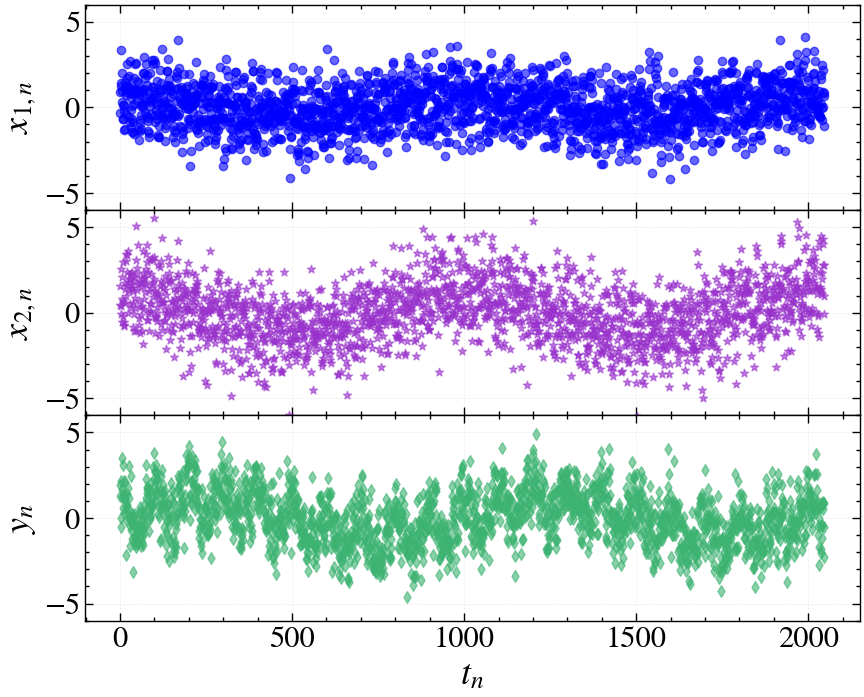

In [8]:
colors = ['b', 'darkorchid', 'mediumseagreen']
markers = ['o', '*', 'd']
ylabels = [r"$x_{1,n}$", r"$x_{2,n}$", r"$y_n$"]
fig, axarr = plt.subplots(3, 1, figsize=(10,8), sharex=True)

for i, ts in enumerate([x1, x2, y]):
    axarr[i].scatter(t, ts, color=colors[i], marker=markers[i], alpha=0.6)
    axarr[i].set_ylabel(ylabels[i])
    axarr[i].set_ylim(-6, 6)
    axarr[i].grid(color='0.85')

axarr[2].set_xlabel(r"$t_n$")
plt.subplots_adjust(hspace=0)

#### Calculate and plot the complex-valued Fourier transforms of $x_{1,n}$, $x_{2,n}$, and $y_n$

In [9]:
from scipy.fft import fft, fftfreq, fftshift

x1_fft = fft(x1)
x2_fft = fft(x2)
y_fft = fft(y)
fgrid = fftfreq(N) # Frequency grid

In [10]:
# Quick lesson in FFT order: frequencies are in increasing order from 0 to just below 0.5, then
#   the grid flips to -0.5 and goes in increasing order up to just below 0. Non-negative frequencies
#   are in gridpoints 0 through N//2-1 (// is floor division)
#   Remember array slice syntax: 0:N//2 doesn't actually include N//2. I use 0:N//2+1 so you can see
#   gridpoint N//2, -0.5 cycles/day.
print(fgrid[:N//2+1])

[ 0.00000000e+00  4.88281250e-04  9.76562500e-04 ...  4.99023438e-01
  4.99511719e-01 -5.00000000e-01]


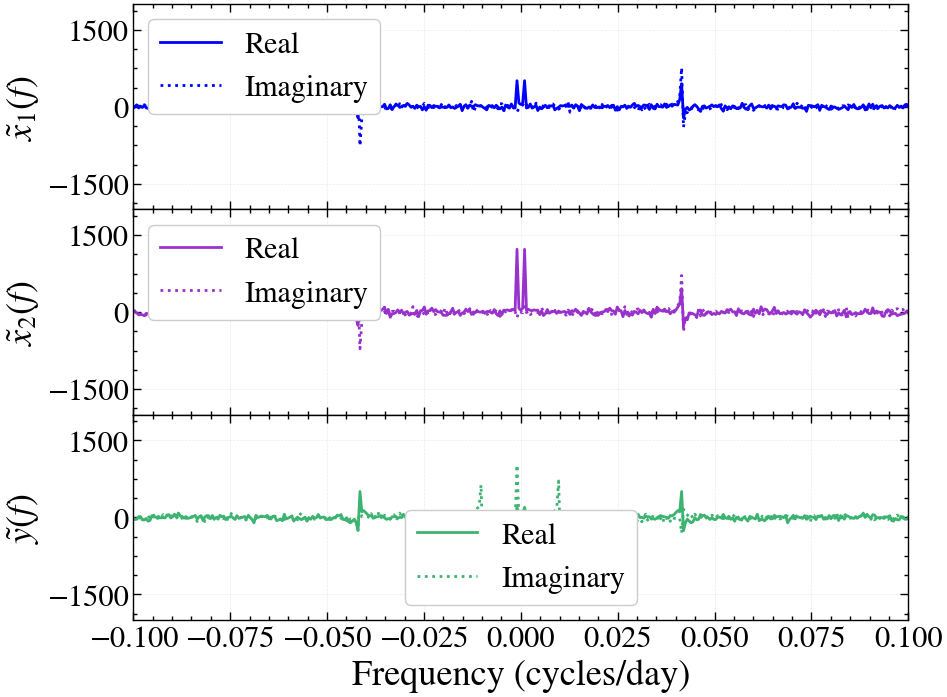

In [11]:
ft_ylabels = [r"$\tilde{x}_1(f)$", r"$\tilde{x}_2(f)$", r"$\tilde{y}(f)$"]
fig, axarr = plt.subplots(3, 1, figsize=(10,8), sharex=True)

for i, ft in enumerate([x1_fft, x2_fft, y_fft]):
    axarr[i].plot(fftshift(fgrid), fftshift(ft.real), color=colors[i], label='Real')
    axarr[i].plot(fftshift(fgrid), fftshift(ft.imag), color=colors[i], ls=':', label='Imaginary')
    axarr[i].set_ylabel(ft_ylabels[i])
    axarr[i].set_ylim([-2000, 2000])
    axarr[i].set_yticks([-1500, 0, 1500])
    axarr[i].grid(color='0.85')
    axarr[i].legend(loc='best', fontsize='small')

axarr[2].set_xlabel("Frequency (cycles/day)")
axarr[2].set_xlim([-0.1, 0.1])
plt.subplots_adjust(hspace=0)

#### Examine RV periodogram

Periodogram is $\hat{S}_{yy}(f) = |\tilde{y}(f)|^2$ (squared absolute value of Fourier transform). When searching for oscillations, we usually look at the periodogram instead of the complex-valued Fourier transform. Peaks correspond to activity, planet, and rotation.

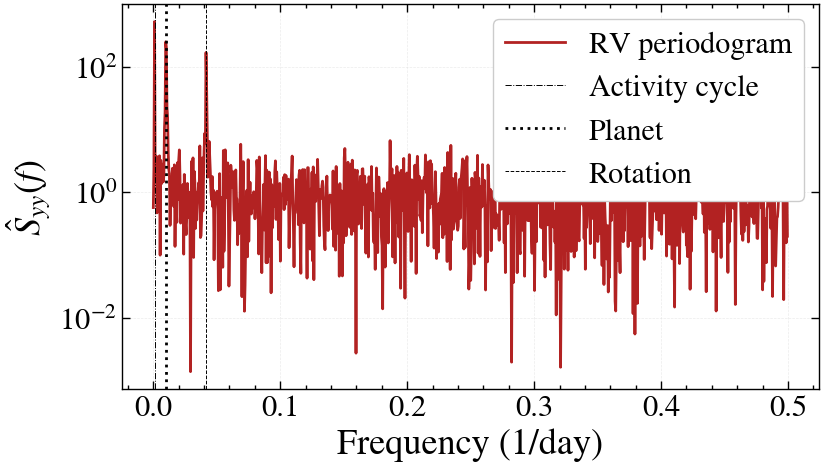

In [12]:
plt.figure(figsize=(9,5))
plt.semilogy(fgrid[:N//2], np.abs(y_fft[:N//2])**2 / N, color='firebrick', label='RV periodogram')
plt.xlabel('Frequency (1/day)')
plt.ylabel(r"$\hat{S}_{yy}(f)$")
plt.axvline(f_a, color='k', ls='-.', lw=0.7, label='Activity cycle')
plt.axvline(f_p, color='k', ls=':', label='Planet')
plt.axvline(f_r, color='k', ls='--', lw=0.7, label='Rotation')
plt.grid(color='0.85')
plt.legend(loc='best', fontsize='small')

### Compute the multiple regression

Formally, the calculation is 

$
  \left[ {\begin{array}{cccccc}
    {\rm Re}[\tilde{x}_1(f_1)] & {\rm Im}[\tilde{x}_1(f_1)] & {\rm Re}[\tilde{x}_2(f_1)] & {\rm Im}[\tilde{x}_2(f_1)] \\
    {\rm Re}[\tilde{x}_1(f_2)] & {\rm Im}[\tilde{x}_1(f_2)] & {\rm Re}[\tilde{x}_2(f_2)] & {\rm Im}[\tilde{x}_2(f_2)] \\
    {\rm Re}[\tilde{x}_1(f_3)] & {\rm Im}[\tilde{x}_1(f_3)] & {\rm Re}[\tilde{x}_2(f_3)] & {\rm Im}[\tilde{x}_2(f_3)] \\
    \vdots & \vdots & \vdots & \vdots \\
    {\rm Re}[\tilde{x}_1(f_{N/2})] & {\rm Im}[\tilde{x}_1(f_{N/2})] & {\rm Re}[\tilde{x}_2(f_{N/2})] & {\rm Im}[\tilde{x}_2(f_{N/2})] & \\
  \end{array} } \right]
  \left[ {\begin{array}{c} \alpha_{\rm Re,1} \\
                           \alpha_{\rm Im,1} \\
                           \alpha_{\rm Re,2} \\
                           \alpha_{\rm Im,2} \\
  \end{array} } \right] = 
  \left[ {\begin{array}{c} {\rm Re}[\tilde{y}(f_1)] \\
                           {\rm Re}[\tilde{y}(f_2)] \\
                           {\rm Re}[\tilde{y}(f_3)] \\
                           \vdots \\
                           {\rm Re}[\tilde{y}(f_{N/2})] \\
  \end{array} } \right]
$

and

$
  \left[ {\begin{array}{cccccc}
    {\rm Re}[\tilde{x}_1(f_1)] & {\rm Im}[\tilde{x}_1(f_1)] & {\rm Re}[\tilde{x}_2(f_1)] & {\rm Im}[\tilde{x}_2(f_1)] \\
    {\rm Re}[\tilde{x}_1(f_2)] & {\rm Im}[\tilde{x}_1(f_2)] & {\rm Re}[\tilde{x}_2(f_2)] & {\rm Im}[\tilde{x}_2(f_2)] \\
    {\rm Re}[\tilde{x}_1(f_3)] & {\rm Im}[\tilde{x}_1(f_3)] & {\rm Re}[\tilde{x}_2(f_3)] & {\rm Im}[\tilde{x}_2(f_3)] \\
    \vdots & \vdots & \vdots & \vdots \\
    {\rm Re}[\tilde{x}_1(f_{N/2})] & {\rm Im}[\tilde{x}_1(f_{N/2})] & {\rm Re}[\tilde{x}_2(f_{N/2})] & {\rm Im}[\tilde{x}_2(f_{N/2})] & \\
  \end{array} } \right]
  \left[ {\begin{array}{c} \beta_{\rm Re,1} \\
                           \beta_{\rm Im,1} \\
                           \beta_{\rm Re,2} \\
                           \beta_{\rm Im,2} \\
  \end{array} } \right] = 
  \left[ {\begin{array}{c} {\rm Im}[\tilde{y}(f_1)] \\
                           {\rm Im}[\tilde{y}(f_2)] \\
                           {\rm Im}[\tilde{y}(f_3)] \\
                           \vdots \\
                           {\rm Im}[\tilde{y}(f_{N/2})] \\
  \end{array} } \right]
$

For each <em>target</em>, ${\rm Re}[\tilde{y}(f)]$ or ${\rm Im}[\tilde{y}(f)]$, we will find the best-fit coefficient vector $\alpha$ or $\beta$. Note that we only use <em>non-negative frequencies</em> in the fits. Recall the idea of a lagged regression; in the frequency domain, lags are encoded as phase shifts. To capture phase shifts, we need to use real parts of $\tilde{x}_1(f)$ and $\tilde{x}_2(f)$ as explanatory variables for the imaginary part of $\tilde{y}(f)$, and vice versa. Real parts of Fourier transforms are even and imaginary parts are odd, so a single scalar coefficient can't express the mapping of real onto imaginary or imaginary onto real if the grid includes negative frequencies.

In [13]:
# rfft is a fast Fourier transform specifically for real-valued input
#    it keeps information about positive frequencies only, which is what we want
# irfft is the inverse of rfft
# rfftfreq gets the positive frequency grid
from scipy.fft import rfft, irfft, rfftfreq

x1_fft_pos = rfft(x1)
x2_fft_pos = rfft(x2)
y_fft_pos = rfft(y)
fgrid_pos = rfftfreq(N)

In [14]:
from sklearn.linear_model import LinearRegression

explanatory = np.column_stack((x1_fft_pos.real, x1_fft_pos.imag, 
                               x2_fft_pos.real, x2_fft_pos.imag))
targets = np.column_stack((y_fft_pos.real, y_fft_pos.imag))

# This line of code finds alpha and beta coefficient vectors at the same time
fd_model = LinearRegression(fit_intercept=False).fit(explanatory, targets)

#### Print out the fit coefficients

Top row is $\alpha$ vector, bottom row is $\beta$ vector. Notice that the real part of $\tilde{x}_2(f)$ is a strong predictor of the imaginary part of $\tilde{y}(f)$. That's as expected: the rotation and activity signals in time series $x_{2,n}$ are cosines, which means they show up in the real part of $\tilde{x}_2(f)$. But the rotation and activity signals in $y_n$ are sines, which land in the imaginary part of $\tilde{y}(f)$.

In [15]:
fd_model.coef_

array([[ 0.11892323,  0.2070804 ,  0.1088018 ,  0.07303658],
       [-0.25057331, -0.08541584, -0.3080831 ,  0.0211622 ]])

### Model predictions

Once the best-fit coefficient vectors $\alpha$ and $\beta$ are found, we get the model predictions by carrying out the multiplications on the left-hand sides of our matrix equations. We will compare the model predictions to the actual $\tilde{y}(f)$.

In [16]:
y_pred = fd_model.predict(explanatory)
print(y_pred.shape)

(1025, 2)


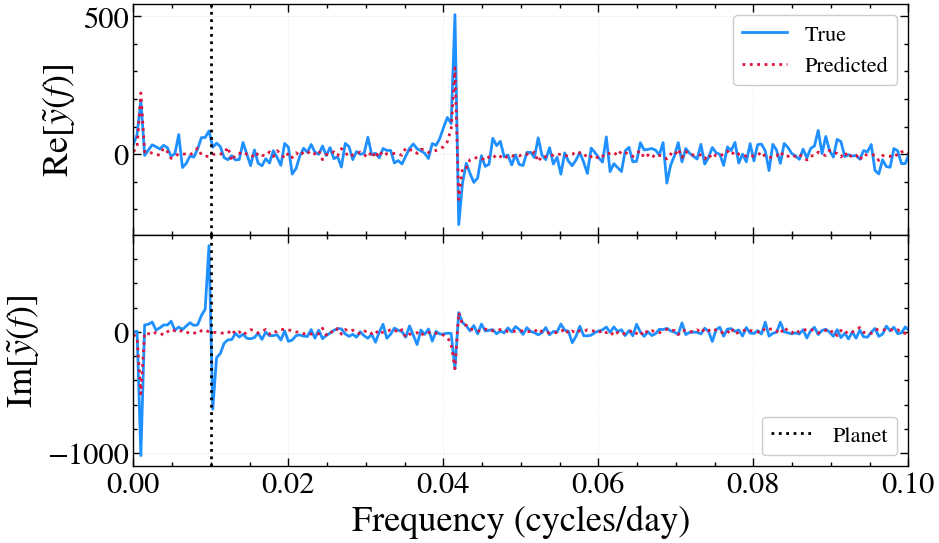

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6))

ax1.plot(fgrid_pos, y_fft_pos.real, color='dodgerblue', label='True')
ax1.plot(fgrid_pos, y_pred[:,0], color='crimson', ls=':', lw=2, label='Predicted')
ax1.set_ylabel(r"Re[$\tilde{y}(f)$]")
ax1.axvline(f_p, color='k', ls=':')
ax1.grid(color='0.85')
ax1.legend(loc='best')

ax2.plot(fgrid_pos, y_fft_pos.imag, color='dodgerblue')
ax2.plot(fgrid_pos, y_pred[:,1], color='crimson', ls=':', lw=2)
ax2.set_ylabel(r"Im[$\tilde{y}(f)$]")
ax2.axvline(f_p, color='k', ls=':', label='Planet')
ax2.grid(color='0.85')
ax2.legend(loc='lower right')
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim([0, 0.1])

plt.subplots_adjust(hspace=0)

Our model is predicting the stellar signals, but leaving the planet signals alone. That's a good sign.

### Inverse FFT back to time domain

Our final goal is to separate the RV contributions from planet(s) and stellar activity. Let's take the inverse fast Fourier transform to get back into the time domain.

In [18]:
fd_activity = y_pred[:,0] + 1j * y_pred[:,1]
activity = irfft(fd_activity)
activity.shape

(2048,)

#### Plot the time-domain RV stellar activity model

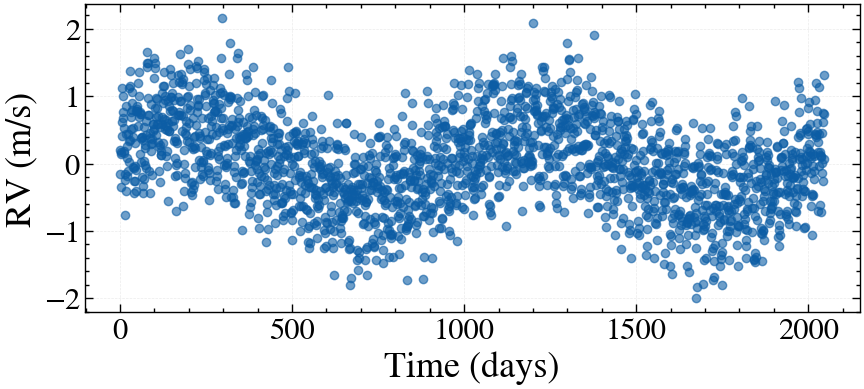

In [19]:
plt.figure(figsize=(10,4))
plt.scatter(t, activity, alpha=0.6)
plt.xlabel('Time (days)')
plt.ylabel('RV (m/s)')
plt.grid(color='0.85')

#### Finally, subtract out the time-domain activity model - planet should remain

In [20]:
resids = y-activity

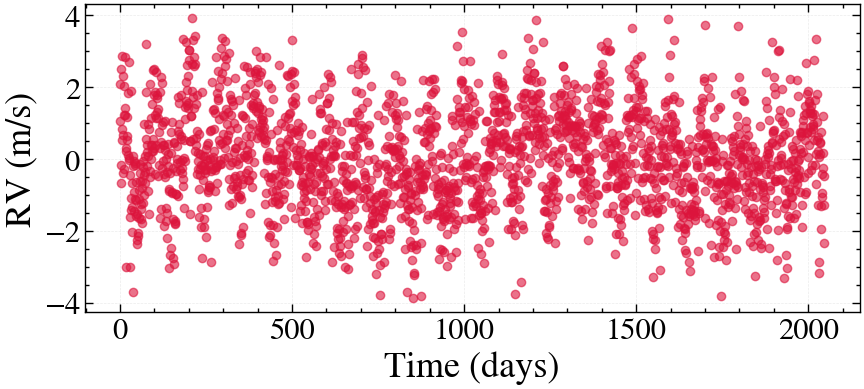

In [21]:
plt.figure(figsize=(10,4))
plt.scatter(t, resids, alpha=0.6, color='crimson')
plt.xlabel('Time (days)')
plt.ylabel('RV (m/s)')
plt.grid(color='0.85')

...and it does! Although we didn't fully get rid of the activity cycle, we attenuated it.

#### Periodogram of residuals - see planet signal

In [22]:
resid_pgram = np.abs(rfft(resids))**2 / N

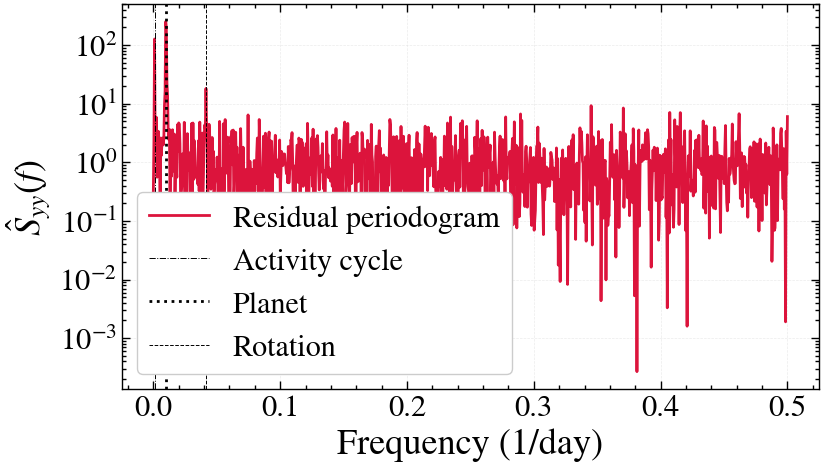

In [23]:
plt.figure(figsize=(9,5))
plt.semilogy(fgrid_pos, resid_pgram, color='crimson', label='Residual periodogram')
plt.xlabel('Frequency (1/day)')
plt.ylabel(r"$\hat{S}_{yy}(f)$")
plt.axvline(f_a, color='k', ls='-.', lw=0.7, label='Activity cycle')
plt.axvline(f_p, color='k', ls=':', label='Planet')
plt.axvline(f_r, color='k', ls='--', lw=0.7, label='Rotation')
plt.grid(color='0.85')
plt.legend(loc='best', fontsize='small')

Planet signal is unattenuated and extremely prominent, while rotation and long-term activity signals are suppressed..

## Repeat the experiment with unevenly spaced data

In the following section we will repeat the procedure but now using the non-uniform FFT computed with <tt>FINUFFT</tt>. The code will now be implemented using the <tt>fdac</tt> library to demonstrate its use following the procedure we showed above but for an unevenly spsaced data set where the observations time are taken from a uniform distribution.

In [24]:
#Compute the unevenly spaced time series
np.random.seed(422)
t_un = np.sort(np.random.uniform(0, N, N)) #The times are picked from a uniform distribution
x1 = np.cos(2*np.pi*f_r*t_un) + 0.5*np.cos(2*np.pi*f_a*t_un) + np.random.randn(N)
x2 = np.cos(2*np.pi*f_r*t_un) + 1.2*np.cos(2*np.pi*f_a*t_un) + 1.3*np.random.randn(N)
y = 0.7*np.sin(2*np.pi*f_r*t_un) + np.sin(2*np.pi*f_a*t_un) \
         + np.cos(2*np.pi*f_p*t_un) + np.random.randn(N)

In [25]:
#Uncomment to have time series with no noise
'''
t_un = np.sort(np.random.uniform(0, N, N)) #The times are picked from a uniform distribution
x1 = np.cos(2*np.pi*f_r*t_un) + 0.5*np.cos(2*np.pi*f_a*t_un) 
x2 = np.cos(2*np.pi*f_r*t_un) + 1.2*np.cos(2*np.pi*f_a*t_un)
y = 0.7*np.sin(2*np.pi*f_r*t_un) + np.sin(2*np.pi*f_a*t_un) \
         + np.cos(2*np.pi*f_p*t_un)
'''

'\nt_un = np.sort(np.random.uniform(0, N, N)) #The times are picked from a uniform distribution\nx1 = np.cos(2*np.pi*f_r*t_un) + 0.5*np.cos(2*np.pi*f_a*t_un) \nx2 = np.cos(2*np.pi*f_r*t_un) + 1.2*np.cos(2*np.pi*f_a*t_un)\ny = 0.7*np.sin(2*np.pi*f_r*t_un) + np.sin(2*np.pi*f_a*t_un)          + np.cos(2*np.pi*f_p*t_un)\n'

Plot the unevenly spaced time series

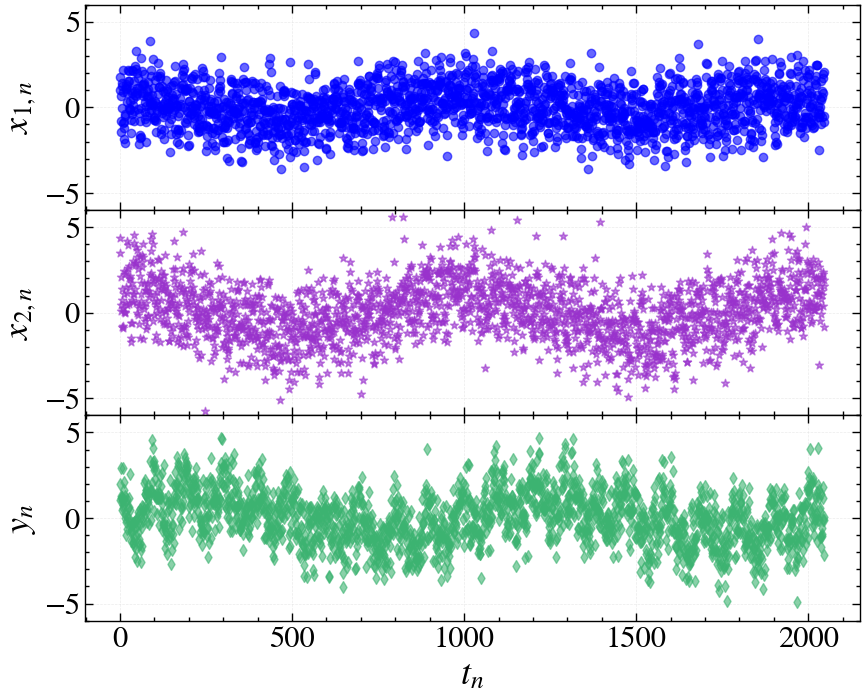

In [26]:
#plot the time series with the new time stamps
colors = ['b', 'darkorchid', 'mediumseagreen']
markers = ['o', '*', 'd']
ylabels = [r"$x_{1,n}$", r"$x_{2,n}$", r"$y_n$"]
fig, axarr = plt.subplots(3, 1, figsize=(10,8), sharex=True)

for i, ts in enumerate([x1, x2, y]):
    axarr[i].scatter(t, ts, color=colors[i], marker=markers[i], alpha=0.6)
    axarr[i].set_ylabel(ylabels[i])
    axarr[i].set_ylim(-6, 6)
    axarr[i].grid(color='0.85')

axarr[2].set_xlabel(r"$t_n$")
plt.subplots_adjust(hspace=0)

In [27]:
import sys
import os

# Get the path to the src folder relative to the notebook
src_path = os.path.abspath(os.path.join(os.pardir, "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

#Import the module
from fdac import fdac

In [28]:
timeseries = np.array((x1, x2))
fdac = fdac.fdac(t_un, y, timeseries, ['y', 'x1', 'x2'])

Mean Nyquist frequency:  0.500027897673218 

Median Nyquist frequency:  0.7479526512232565 

10% trimmed Mean Nyquist frequency:  0.568517800622527 

20% trimmed mean Nyqusit frequenct:  0.6148312770840836


#### Compute the NFFT of each time series

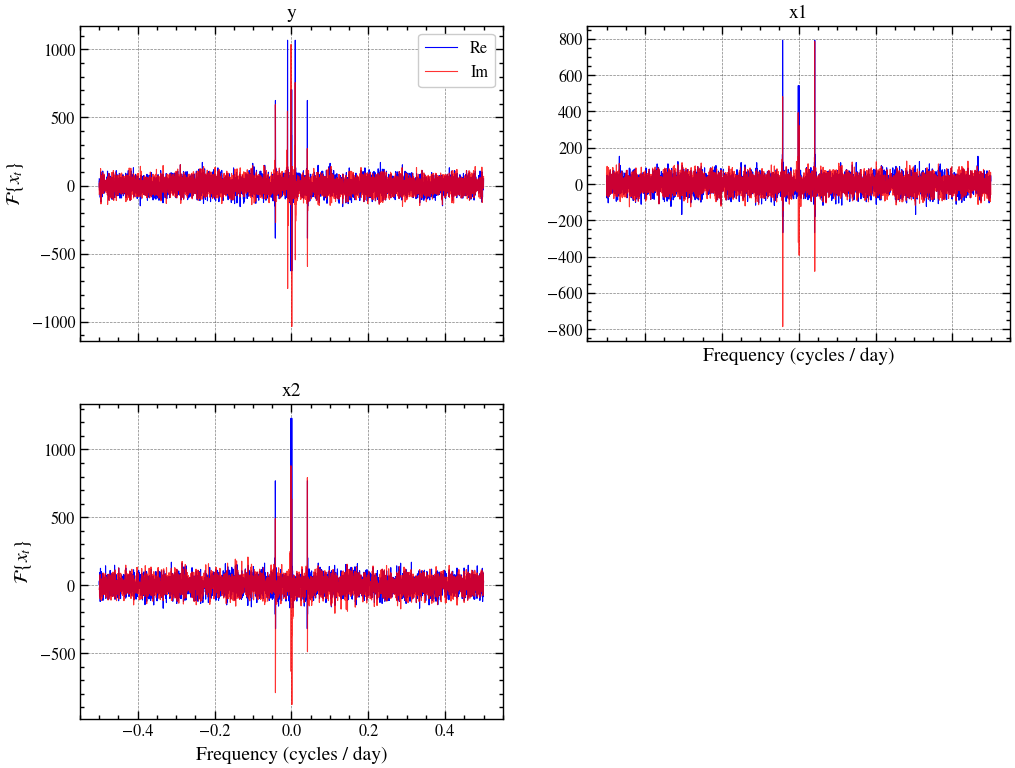

In [29]:
fdac.frequency_grid(fdac.Nyq_meandt, oversample=2)
fdac.computeNFFT()
fdac.plotNFFT()

## Compute the Multiple Linear Regression

In [30]:
fdac.linear_reg()

Coefficients
----
Coefficients: 
 [[-0.05206577  0.18470288  0.02778402  0.17186409]
 [-0.18419967 -0.05144128 -0.18913162  0.02648052]]

Intercept
---------
Intercept: 
 0.0


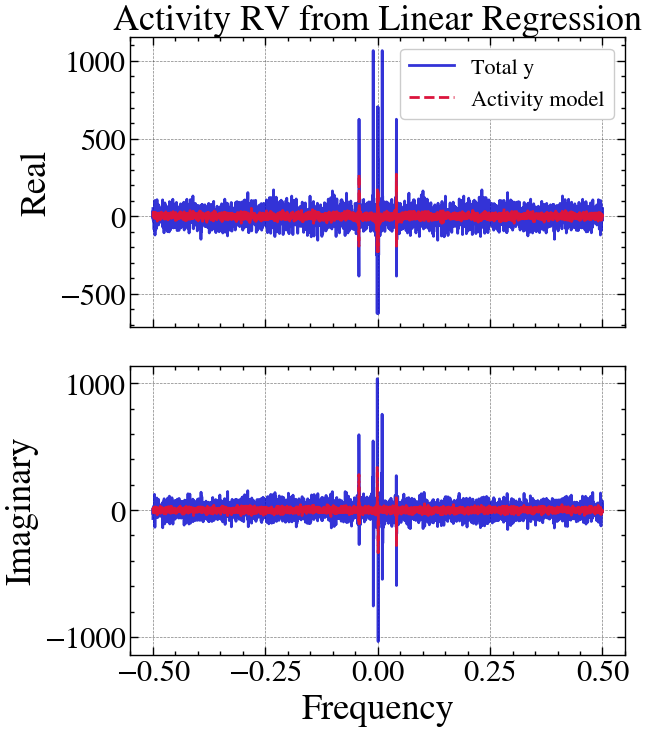

In [37]:
fdac.fftac_plot()

#### Invert back to the Time domain

Raw standard deviation 1.5253
Inversion fully computed
Std dev of clean RV: 1.5552882671112394


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


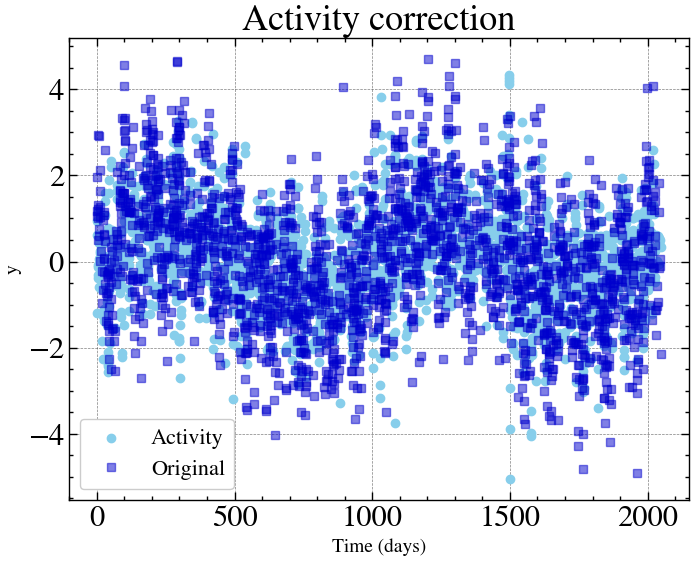

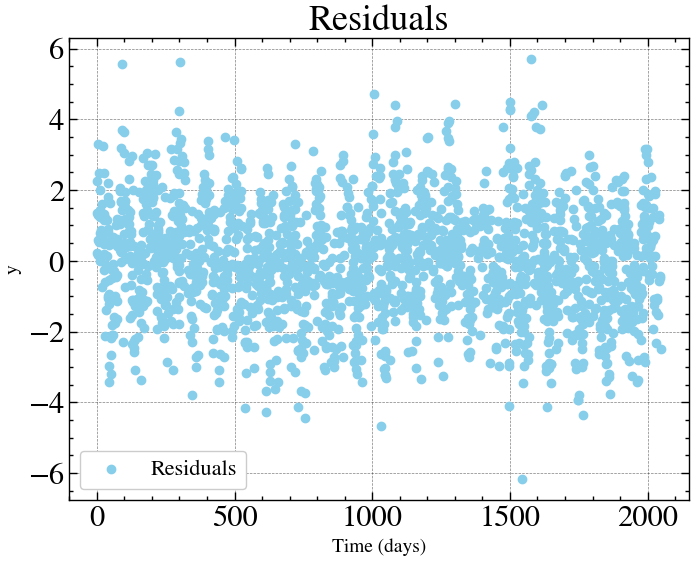

In [32]:
fdac.inverfft()
fdac.activityplot(clean = True)

#### Subtract the activity model and check the periodogram

(-0.01, 0.5)

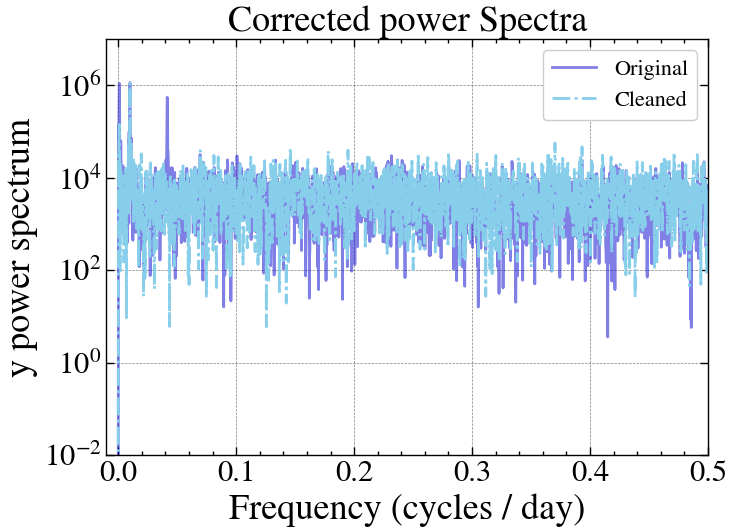

In [36]:
fdac.residual_powplot(log=True)
plt.ylim(1e-2, 1e7)
plt.xlim(-0.01,0.5)

There is a significant subtraction of the roation period compared to the original periodogram